# Phase 1 — Customer Churn EDA

## Goal

In this notebook, we explore the IBM Telco Customer Churn dataset before training machine learning models.

Simple meaning: we are trying to understand **who leaves, who stays, and what patterns might explain customer churn**.

Professional meaning: this EDA helps us detect class imbalance, missing values, suspicious columns, leakage risks, and useful business signals before modeling.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

# Robust path handling: works whether notebook runs from project root or notebooks folder
PROJECT_ROOT = Path.cwd()
DATA_PATH = PROJECT_ROOT / "data/raw/telco_churn_ibm.csv"

if not DATA_PATH.exists():
    DATA_PATH = PROJECT_ROOT.parent / "data/raw/telco_churn_ibm.csv"

print("Using dataset path:")
print(DATA_PATH)

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())


Using dataset path:
/Users/claraamir/Documents/ArabiQ-Arabic-Customer-Intelligence/data/raw/telco_churn_ibm.csv
Shape: (7043, 33)

First 5 rows:


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices



Column names:
['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']


## 1. Basic Dataset Inspection

We first check:
- how many rows and columns we have,
- the data type of each column,
- missing values,
- and the target distribution.

The target column is `Churn Label`, which tells us whether the customer left the company or stayed.


In [2]:
print("Data types:")
display(df.dtypes)

print("\nMissing values:")
missing_values = df.isnull().sum().sort_values(ascending=False)
display(missing_values[missing_values > 0])

print("\nTarget distribution:")
display(df["Churn Label"].value_counts())

churn_rate = df["Churn Label"].eq("Yes").mean()
print(f"\nChurn rate: {churn_rate:.3f} ({churn_rate:.1%})")


Data types:


CustomerID               str
Count                  int64
Country                  str
State                    str
City                     str
Zip Code               int64
Lat Long                 str
Latitude             float64
Longitude            float64
Gender                   str
Senior Citizen           str
Partner                  str
Dependents               str
Tenure Months          int64
Phone Service            str
Multiple Lines           str
Internet Service         str
Online Security          str
Online Backup            str
Device Protection        str
Tech Support             str
Streaming TV             str
Streaming Movies         str
Contract                 str
Paperless Billing        str
Payment Method           str
Monthly Charges      float64
Total Charges            str
Churn Label              str
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason             str
dtype: object


Missing values:


Churn Reason    5174
dtype: int64


Target distribution:


Churn Label
No     5174
Yes    1869
Name: count, dtype: int64


Churn rate: 0.265 (26.5%)


## 2. Class Imbalance

Simple meaning: if many more customers stayed than left, a model might become lazy and mostly predict “No churn.”

Professional meaning: this is a binary classification problem with class imbalance, so accuracy alone is not enough. We will later use AUC-ROC, F1, precision, and recall.


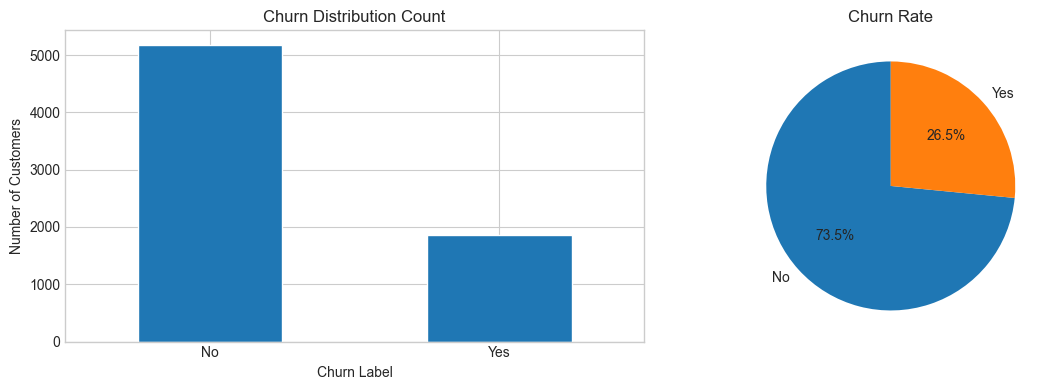

In [3]:
# Robust charts path:
# If the notebook runs from the project root, save to reports/charts.
# If the notebook runs from inside notebooks/, still save to the root reports/charts.
current_dir = Path.cwd()

if (current_dir / "data/raw/telco_churn_ibm.csv").exists():
    project_root = current_dir
else:
    project_root = current_dir.parent

charts_dir = project_root / "reports/charts"
charts_dir.mkdir(parents=True, exist_ok=True)

print("Charts will be saved to:")
print(charts_dir.resolve())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["Churn Label"].value_counts().plot(
    kind="bar",
    ax=axes[0],
    edgecolor="white"
)
axes[0].set_title("Churn Distribution Count")
axes[0].set_xlabel("Churn Label")
axes[0].set_ylabel("Number of Customers")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

df["Churn Label"].value_counts().plot(
    kind="pie",
    ax=axes[1],
    autopct="%1.1f%%",
    startangle=90
)
axes[1].set_title("Churn Rate")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig(charts_dir / "churn_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


### Interpretation

Write your interpretation here after running the cell.

Suggested starting point:

The dataset shows that most customers did not churn, while a smaller but important percentage did churn. This means the dataset is moderately imbalanced. Accuracy alone can be misleading because a model could predict “No churn” most of the time and still look good. For this reason, we will later evaluate models using AUC-ROC, F1 score, precision, and recall.


## 3. Churn by Contract Type

Contract type is usually one of the strongest churn predictors. Customers with short-term contracts are often easier to lose than customers with long-term contracts.


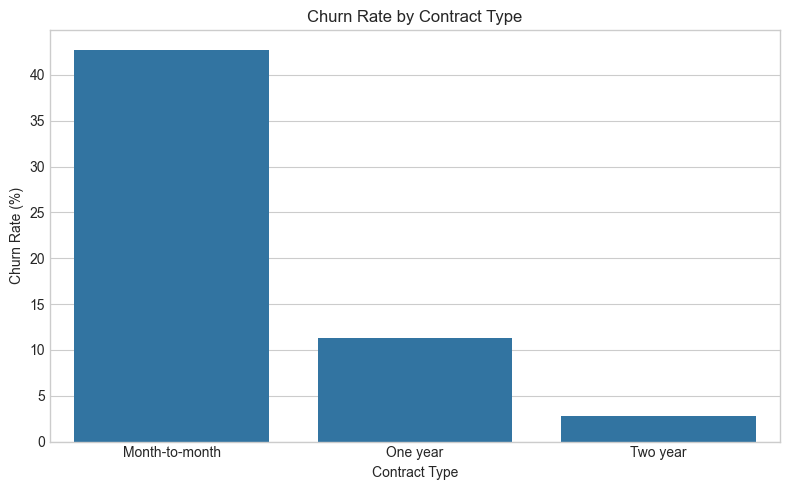

,Contract,Churn Rate (%)
0,Month-to-month,42.709677
1,One year,11.269518
2,Two year,2.831858


In [4]:
contract_churn = (
    df.groupby("Contract")["Churn Label"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index()
)

contract_churn.columns = ["Contract", "Churn Rate (%)"]

plt.figure(figsize=(8, 5))
sns.barplot(data=contract_churn, x="Contract", y="Churn Rate (%)")
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Contract Type")
plt.tight_layout()
plt.savefig(charts_dir / "churn_by_contract.png", dpi=150, bbox_inches="tight")
plt.show()

display(contract_churn)


### Interpretation

Write your interpretation here after running the cell.

Look especially at whether month-to-month customers churn more than one-year or two-year customers.


## 4. Numeric Feature Correlation with Churn

We convert the target into a number:

- `Yes` = 1
- `No` = 0

Then we check which numeric columns move most strongly with churn.


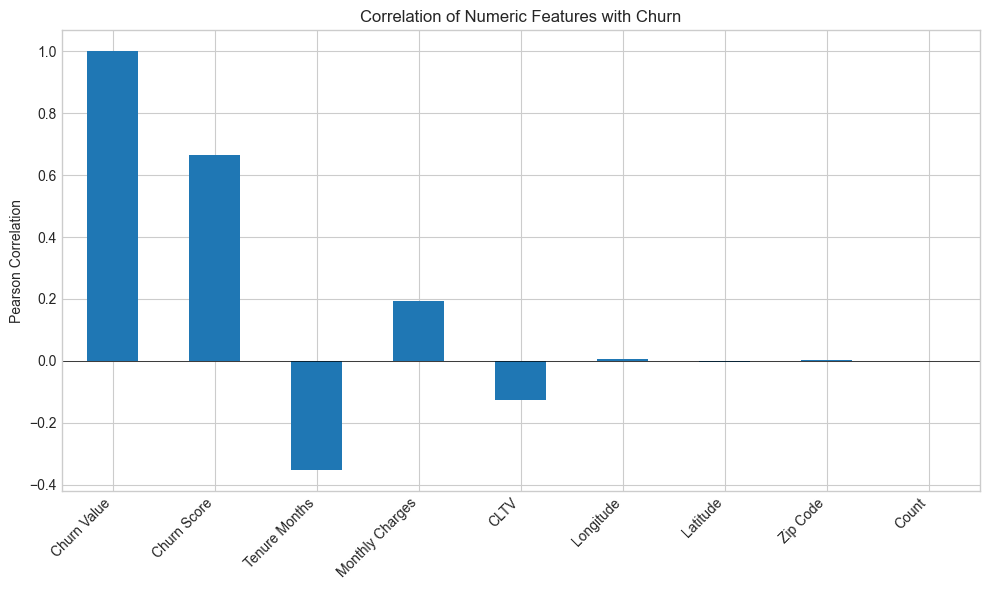

Churn Value        1.000000
Churn Score        0.664897
Tenure Months     -0.352229
Monthly Charges    0.193356
CLTV              -0.127463
Longitude          0.004594
Latitude          -0.003384
Zip Code           0.003346
Count                   NaN
Name: churn_binary, dtype: float64

In [5]:
df_corr = df.copy()
df_corr["churn_binary"] = (df_corr["Churn Label"] == "Yes").astype(int)

numeric_cols = df_corr.select_dtypes(include=[np.number]).columns.tolist()

churn_corr = (
    df_corr[numeric_cols]
    .corr()["churn_binary"]
    .drop("churn_binary")
    .sort_values(key=abs, ascending=False)
)

plt.figure(figsize=(10, 6))
churn_corr.plot(kind="bar")
plt.title("Correlation of Numeric Features with Churn")
plt.ylabel("Pearson Correlation")
plt.axhline(y=0, color="black", linewidth=0.5)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(charts_dir / "feature_correlations.png", dpi=150, bbox_inches="tight")
plt.show()

display(churn_corr)


## 5. Leakage Warning

The guide warns us not to use columns like:

- `Churn Score`
- `CLTV`
- `Churn Reason`
- `Churn Value`

These columns are dangerous for modeling because they may already contain information related to the answer. This is called **data leakage**.

Simple meaning: it is like giving the model the answer key during training.

Professional meaning: leakage causes unrealistically high model performance and makes the model unreliable in real deployment.


In [6]:
leakage_columns = ["Churn Score", "CLTV", "Churn Reason", "Churn Value"]

print("Potential leakage columns found in dataset:")
for col in leakage_columns:
    print(f"- {col}:", col in df.columns)


Potential leakage columns found in dataset:
- Churn Score: True
- CLTV: True
- Churn Reason: True
- Churn Value: True
